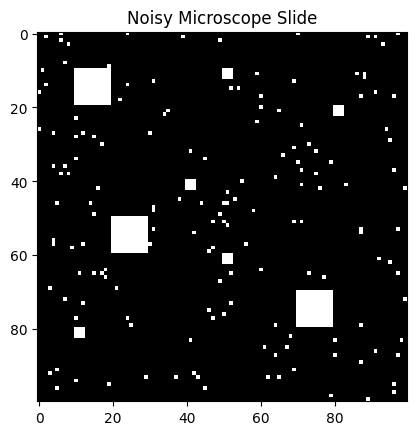

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import ndimage

slide = np.zeros((100, 100), dtype=np.uint8)


for loc in [(10,10), (50,20), (70,70)]:
    slide[loc[0]:loc[0]+10, loc[1]:loc[1]+10] = 1


for loc in [(20,80), (40,40), (80,10), (10,50), (60,50)]:
    slide[loc[0]:loc[0]+3, loc[1]:loc[1]+3] = 1


noise = np.random.rand(100, 100) > 0.98
slide = np.logical_or(slide, noise).astype(np.uint8)

plt.imshow(slide, cmap='gray')
plt.title("Noisy Microscope Slide")
plt.show()

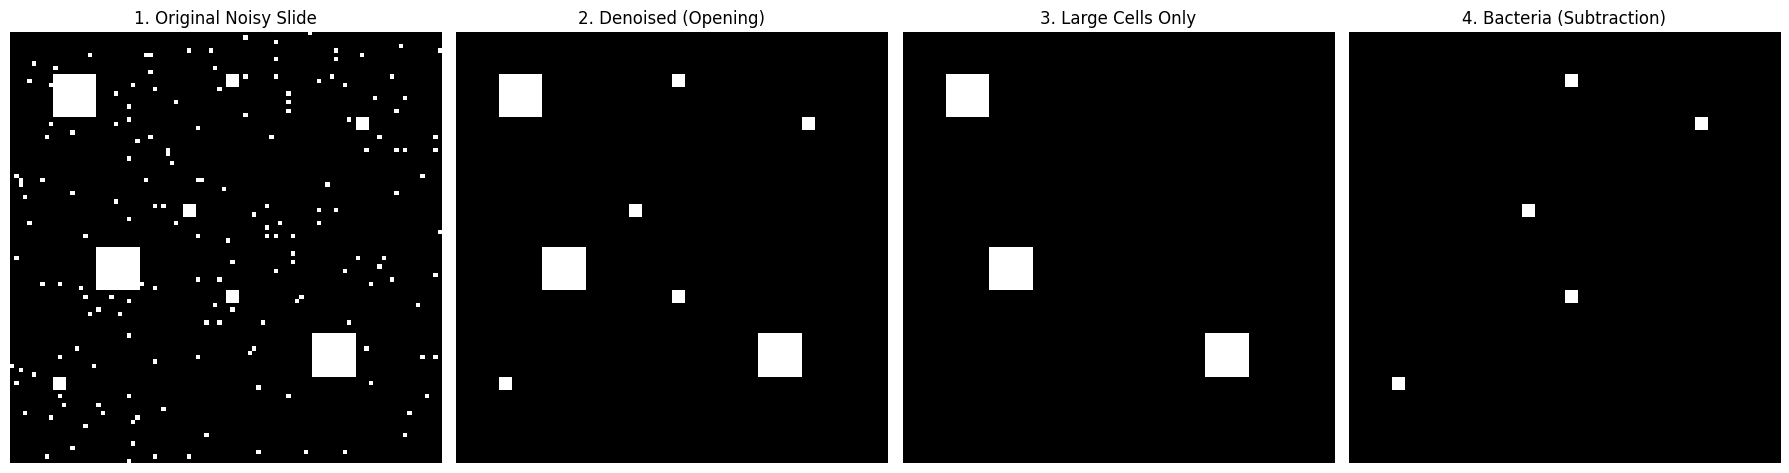

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import ndimage

slide = np.zeros((100, 100), dtype=np.uint8)


for loc in [(10,10), (50,20), (70,70)]:
    slide[loc[0]:loc[0]+10, loc[1]:loc[1]+10] = 1


for loc in [(20,80), (40,40), (80,10), (10,50), (60,50)]:
    slide[loc[0]:loc[0]+3, loc[1]:loc[1]+3] = 1


np.random.seed(42)
noise = np.random.rand(100, 100) > 0.98
slide = np.logical_or(slide, noise).astype(np.uint8)


se_noise = np.ones((2, 2))
denoised = ndimage.binary_opening(slide, structure=se_noise).astype(np.uint8)

se_large = np.ones((5, 5))
large_cells = ndimage.binary_opening(denoised, structure=se_large).astype(np.uint8)


bacteria_only = (denoised - large_cells).astype(np.uint8)

labeled_b, num_b = ndimage.label(bacteria_only)

labeled_c, num_c = ndimage.label(large_cells)

cell_area = np.sum(large_cells)


fig, axes = plt.subplots(1, 4, figsize=(18, 5))
titles = ["1. Original Noisy Slide", "2. Denoised (Opening)",
          "3. Large Cells Only", "4. Bacteria (Subtraction)"]
images = [slide, denoised, large_cells, bacteria_only]

for ax, img, title in zip(axes, images, titles):
    ax.imshow(img, cmap='gray')
    ax.set_title(title)
    ax.axis('off')

plt.tight_layout()
plt.show()

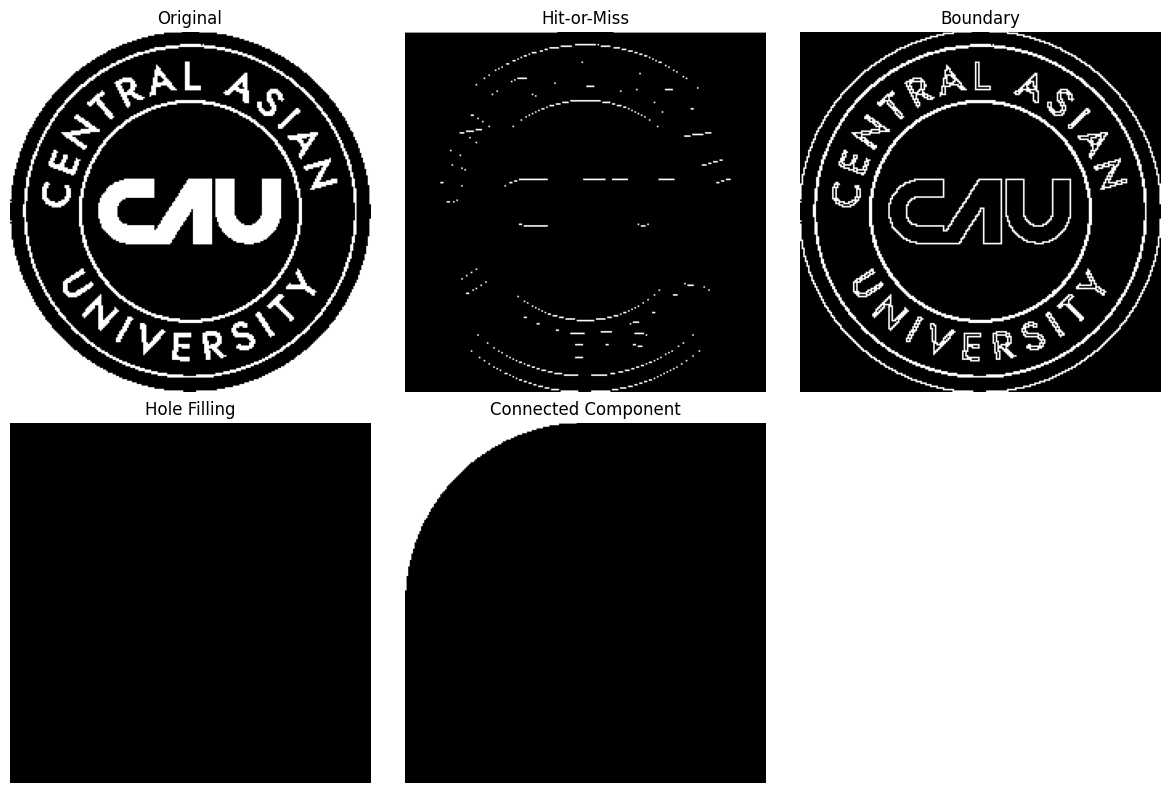

In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

img = cv2.imread("/content/images.jpg", 0)
_, binary = cv2.threshold(img, 127, 255, cv2.THRESH_BINARY)

# Hit-or-Miss
binary01 = (binary // 255).astype(np.uint8)
kernel = np.array([[-1,-1,-1],
                   [ 0, 1, 0],
                   [ 1, 1, 1]], dtype=np.int8)
hitmiss = cv2.morphologyEx(binary01, cv2.MORPH_HITMISS, kernel) * 255

# Boundary Extraction
se = np.ones((3,3), np.uint8)
boundary = cv2.subtract(binary, cv2.erode(binary, se))

# Hole Filling
mask = np.zeros((binary.shape[0]+2, binary.shape[1]+2), np.uint8)
flood = binary.copy()
cv2.floodFill(flood, mask, (0,0), 255)
holes = cv2.bitwise_not(flood)
filled = cv2.bitwise_or(binary, holes)

# Connected Components
num_labels, labels = cv2.connectedComponents(binary)
component = np.zeros_like(binary)
if num_labels > 1:
    component[labels == 1] = 255

# Display
plt.figure(figsize=(12,8))
plt.subplot(231), plt.imshow(binary, cmap='gray'), plt.title("Original"), plt.axis("off")
plt.subplot(232), plt.imshow(hitmiss, cmap='gray'), plt.title("Hit-or-Miss"), plt.axis("off")
plt.subplot(233), plt.imshow(boundary, cmap='gray'), plt.title("Boundary"), plt.axis("off")
plt.subplot(234), plt.imshow(filled, cmap='gray'), plt.title("Hole Filling"), plt.axis("off")
plt.subplot(235), plt.imshow(component, cmap='gray'), plt.title("Connected Component"), plt.axis("off")
plt.tight_layout()
plt.show()